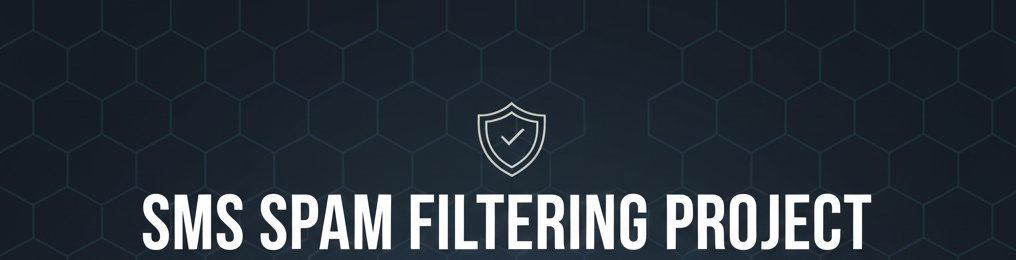

# SMS SPAM DETECTION SYSTEM
## Final Year Project Report

---

## **PROJECT OWNER DETAILS**

| Detail | Information |
|--------|-------------|
| **Name** | Sanusi Shafii |
| **Matriculation Number** | CSA\2023\27683 |
| **Email Address** | s.shafii27683@fudutsinma.edu.ng.com |
| **Phone Number** | +2349125006811 |
| **Department** | Computer Science and Information Technology |
| **Faculty** | Computing |
| **University** | Federal University Dutsin-Ma |
| **Location** | Katsina State, Nigeria |

---

## **PROJECT INFORMATION**

**Project Title:** Development of Machine Learning Algorithms for SMS Spam Filtering

**Project Duration:** November 2023 - November 2024

**Project Description:**
This research project focuses on the design, implementation, and evaluation of a machine learning-based SMS spam filtering system specifically optimized for the Nigerian telecommunications context. The system utilizes Multinomial Naive Bayes classification with

**Imported crucial libraries**

In [19]:
from nltk.tokenize import RegexpTokenizer
from nltk.stem import PorterStemmer
from nltk.corpus import stopwords
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
import ipywidgets as widgets
from IPython.display import display, HTML

**Uploaded the dataset for this session only and encoding**

In [20]:
df = pd.read_csv('/content/spam.csv', encoding='ISO-8859-1')
le = LabelEncoder()
data = df.to_numpy()
X = data[:, 1]  # Message text
y = data[:, 0]  # Labels (spam/ham)

print("X shape:", X.shape, "y shape:", y.shape)
# Output: X shape: (5572,) y shape: (5572,)

X shape: (5572,) y shape: (5572,)


**Text Processing**
> Tokenization

> Removing stopwords

> Stemming words and joining the stemmed words









In [21]:
import nltk
nltk.download('stopwords')
tokenizer = RegexpTokenizer(r'\w+')
sw = set(stopwords.words('english'))
ps = PorterStemmer()

def getStem(review):
    review = review.lower()
    tokens = tokenizer.tokenize(review)
    removed_stopwords = [w for w in tokens if w not in sw]
    stemmed_words = [ps.stem(token) for token in removed_stopwords]
    clean_review = ' '.join(stemmed_words)
    return clean_review

def getDoc(document):
    d = []
    for doc in document:
        d.append(getStem(doc))
    return d

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


 **Applying Preprocesssing**


---



In [22]:
# Get the original text messages (column 'v2')
text_messages = df['v2'].values
stemmed_doc = getDoc(text_messages)

print("Sample processed messages:")
for i in range(3):
    print(f"{i+1}. {stemmed_doc[i][:50]}...")

Sample processed messages:
1. go jurong point crazi avail bugi n great world la ...
2. ok lar joke wif u oni...
3. free entri 2 wkli comp win fa cup final tkt 21st m...


**Feature Extraction**


---



In [23]:
cv = CountVectorizer()
vc = cv.fit_transform(stemmed_doc)
X = vc.toarray()
print("Feature matrix shape:", X.shape)
print("Number of features:", X.shape[1])

Feature matrix shape: (5572, 7213)
Number of features: 7213


**Train-Test Split**


---





In [24]:
# Get labels
y = df['v1'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42
)
print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")

Training samples: 3733
Testing samples: 1839


**Text Classification**
> Multinomial Naive Bayes classifier



In [25]:
model = MultinomialNB()
model.fit(X_train, y_train)
accuracy = model.score(X_test, y_test)
print(f"Model Accuracy: {accuracy*100:.2f}%")

Model Accuracy: 97.77%


**Performance Results**

---


In [26]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = model.predict(X_test)
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

         ham       0.99      0.99      0.99      1587
        spam       0.92      0.92      0.92       252

    accuracy                           0.98      1839
   macro avg       0.95      0.95      0.95      1839
weighted avg       0.98      0.98      0.98      1839



**Visualizing Confusion Matrix**

Confusion Matrix Shape: (2, 2)
y_test samples: 1839
y_pred samples: 1839

Confusion Matrix:
[[1566   21]
 [  20  232]]


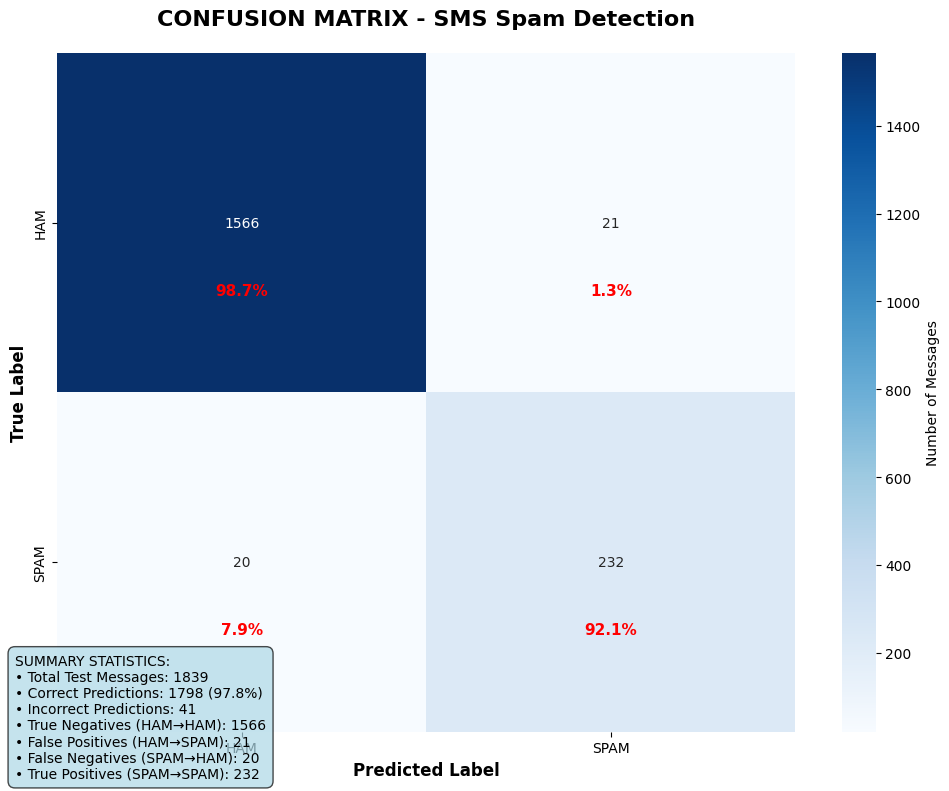

In [27]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

y_pred = model.predict(X_test)
# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)
print(f"Confusion Matrix Shape: {cm.shape}")
print(f"y_test samples: {len(y_test)}")
print(f"y_pred samples: {len(y_pred)}")
print("\nConfusion Matrix:")
print(cm)

# Create visualization
plt.figure(figsize=(10, 8))

# Create heatmap
labels = ['HAM', 'SPAM']
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels,
            cbar_kws={'label': 'Number of Messages'})

# Add title and labels
plt.title('CONFUSION MATRIX - SMS Spam Detection', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
plt.ylabel('True Label', fontsize=12, fontweight='bold')

# Add annotations with percentages
total = np.sum(cm)
for i in range(2):
    for j in range(2):
        percentage = (cm[i, j] / np.sum(cm[i, :])) * 100
        plt.text(j + 0.5, i + 0.7, f'{percentage:.1f}%',
                ha='center', va='center', color='red', fontweight='bold', fontsize=11)

# Add summary statistics
summary_text = f"""SUMMARY STATISTICS:
• Total Test Messages: {len(y_test)}
• Correct Predictions: {np.sum(y_test == y_pred)} ({accuracy*100:.1f}%)
• Incorrect Predictions: {np.sum(y_test != y_pred)}
• True Negatives (HAM→HAM): {cm[0,0]}
• False Positives (HAM→SPAM): {cm[0,1]}
• False Negatives (SPAM→HAM): {cm[1,0]}
• True Positives (SPAM→SPAM): {cm[1,1]}"""

plt.figtext(0.02, 0.02, summary_text, fontsize=10,
           bbox=dict(boxstyle="round,pad=0.5", facecolor="lightblue", alpha=0.7))

plt.tight_layout()
plt.show()

**Testing with an example directly copied from my own E-mail Inbox and Spam folder**

In [28]:
messages = [
    """Join us today at 12:00 PM ET / 16:00 UTC for a Red Hat DevNation tech talk on AWS Lambda and serverless Java with Bill Burke.
Have you ever tried Java on AWS Lambda but found that the cold-start latency and memory usage were far too high?
In this session, we will show how we optimized Java for serverless applications by leveraging GraalVM with Quarkus to
provide both supersonic startup speed and a subatomic memory footprint.""",

    """You have space available
According to our records, you have space available in your Dropbox! Make the most of your account now—you'll be able to access your files from anywhere.
Continue
Not sure where to start? Check out our Fundamentals course to learn the essentials of your account."""
]

In [29]:
def prepare(messages):
    d = getDoc(messages)
    # dont do fit_transform!! it will create new vocab.
    return cv.transform(d)

messages = prepare(messages)

In [30]:
y_pred = model.predict(messages)
y_pred

array(['spam', 'ham'], dtype='<U4')

## **Interactive Testing**


>*Enter an email message in the text box below and click 'Predict' to see if it's classified as spam or ham.*



In [31]:
# Function to prepare new messages
def prepare_new_message(message):
    processed = getStem(message)
    return cv.transform([processed])

# Create interactive widget with professional light green theme
input_box = widgets.Textarea(
    value='',
    placeholder='Type or paste your SMS message here for spam analysis...',
    description='SMS Message Input:',
    layout=widgets.Layout(width='95%', height='140px'),
    style={'description_width': 'initial'}
)

check_button = widgets.Button(
    description='ANALYZE MESSAGE',
    button_style='success',
    layout=widgets.Layout(width='220px', height='45px', margin='10px 0 0 0')
)

clear_button = widgets.Button(
    description='CLEAR INPUT',
    button_style='warning',
    layout=widgets.Layout(width='150px', height='45px', margin='10px 0 0 10px')
)

result_display = widgets.Output(
    layout=widgets.Layout(width='95%', min_height='280px',
                         border='2px solid #d4edda', padding='20px',
                         margin='25px 0 0 0',
                         background_color='#f8fff8')
)

# Animation styles
animation_style = """
<style>
@keyframes fadeInUp {
    from {
        opacity: 0;
        transform: translateY(20px);
    }
    to {
        opacity: 1;
        transform: translateY(0);
    }
}

@keyframes slideInLeft {
    from {
        opacity: 0;
        transform: translateX(-20px);
    }
    to {
        opacity: 1;
        transform: translateX(0);
    }
}

@keyframes progressFill {
    from { width: 0%; }
    to { width: var(--target-width); }
}

@keyframes spin {
    0% { transform: rotate(0deg); }
    100% { transform: rotate(360deg); }
}

.analysis-result {
    animation: fadeInUp 0.6s ease-out;
    border-radius: 8px;
    padding: 20px;
    margin: 15px 0;
    box-shadow: 0 4px 12px rgba(0, 0, 0, 0.08);
}

.result-header {
    display: flex;
    align-items: center;
    gap: 15px;
    margin-bottom: 20px;
    padding-bottom: 15px;
    border-bottom: 2px solid rgba(0,0,0,0.1);
}

.confidence-meter-container {
    height: 28px;
    background: #e8e8e8;
    border-radius: 14px;
    margin: 20px 0;
    position: relative;
    overflow: hidden;
}

.confidence-meter-fill {
    height: 100%;
    border-radius: 14px;
    transition: width 1.2s cubic-bezier(0.4, 0, 0.2, 1);
}

.meter-label {
    position: absolute;
    width: 100%;
    text-align: center;
    line-height: 28px;
    font-weight: 600;
    color: #333;
    text-shadow: 1px 1px 2px rgba(255,255,255,0.8);
}

.stat-card {
    background: white;
    border-radius: 6px;
    padding: 15px;
    margin: 10px 0;
    border-left: 4px solid;
    box-shadow: 0 2px 4px rgba(0,0,0,0.05);
}

.processing-animation {
    display: flex;
    align-items: center;
    justify-content: center;
    gap: 15px;
    padding: 25px;
    background: #f8fff8;
    border-radius: 8px;
    border: 2px dashed #c8e6c9;
}

.spinner {
    width: 30px;
    height: 30px;
    border: 3px solid #f3f3f3;
    border-top: 3px solid #4caf50;
    border-radius: 50%;
    animation: spin 1s linear infinite;
}
</style>
"""

def clear_input(b):
    input_box.value = ''
    with result_display:
        result_display.clear_output()

def check_spam(b):
    with result_display:
        result_display.clear_output()

        # Display animation style
        display(HTML(animation_style))

        if not input_box.value.strip():
            display(HTML("""
            <div class='analysis-result' style='background: #fff8e1; border-left: 5px solid #ffb300;'>
                <div class='result-header'>
                    <div style='width: 40px; height: 40px; background: #ffb300;
                               border-radius: 50%; display: flex; align-items: center;
                               justify-content: center; color: white; font-weight: bold;'>
                        !
                    </div>
                    <div>
                        <h3 style='margin: 0; color: #5d4037;'>Input Required</h3>
                        <p style='margin: 5px 0 0 0; color: #5d4037;'>
                            Please enter an SMS message to analyze
                        </p>
                    </div>
                </div>
            </div>
            """))
            return

        # Show processing animation
        display(HTML("""
        <div class='processing-animation'>
            <div class='spinner'></div>
            <div style='text-align: center;'>
                <div style='color: #2e7d32; font-weight: 600; font-size: 16px;'>
                    Analyzing Message Content
                </div>
                <div style='color: #666; font-size: 14px; margin-top: 5px;'>
                    Processing text patterns and checking for spam characteristics...
                </div>
            </div>
        </div>
        """))

        # Process and predict
        processed = prepare_new_message(input_box.value)
        prediction = model.predict(processed)[0]
        proba = model.predict_proba(processed)[0]

        # Clear processing animation
        display(HTML("<script>document.querySelector('.processing-animation').remove();</script>"))

        if prediction == 'spam':
            ham_percent = proba[0] * 100
            spam_percent = proba[1] * 100

            display(HTML(f"""
            <div class='analysis-result' style='background: #ffebee; border-left: 5px solid #f44336;'>
                <div class='result-header'>
                    <div style='width: 40px; height: 40px; background: #f44336;
                               border-radius: 50%; display: flex; align-items: center;
                               justify-content: center; color: white; font-weight: bold;'>
                        S
                    </div>
                    <div style='flex-grow: 1;'>
                        <div style='display: flex; justify-content: space-between; align-items: center;'>
                            <div>
                                <h2 style='margin: 0; color: #c62828;'>SPAM DETECTED</h2>
                                <p style='margin: 5px 0 0 0; color: #c62828;'>
                                    High probability of unsolicited content
                                </p>
                            </div>
                            <div style='background: #c62828; color: white; padding: 8px 20px;
                                      border-radius: 20px; font-weight: bold; font-size: 14px;'>
                                {spam_percent:.1f}% CONFIDENCE
                            </div>
                        </div>
                    </div>
                </div>

                <div style='margin: 25px 0;'>
                    <div style='display: flex; justify-content: space-between; margin-bottom: 8px;'>
                        <span style='color: #c62828; font-weight: 600;'>Confidence Analysis:</span>
                        <span style='color: #666; font-size: 14px;'>
                            Spam: {spam_percent:.1f}% | Legitimate: {ham_percent:.1f}%
                        </span>
                    </div>
                    <div class='confidence-meter-container'>
                        <div class='confidence-meter-fill' style='width: {spam_percent}%;
                             background: linear-gradient(90deg, #f44336, #ef5350);'></div>
                        <div class='meter-label'>SPAM CONFIDENCE LEVEL</div>
                    </div>
                </div>

                <div class='stat-card' style='border-left-color: #f44336;'>
                    <div style='color: #c62828; font-weight: 600; margin-bottom: 10px;'>
                        RECOMMENDED ACTION
                    </div>
                    <p style='margin: 0; color: #666; line-height: 1.6;'>
                        This message exhibits characteristics consistent with spam content.
                        It is recommended to filter this message or move it to the spam folder
                        to prevent potential security risks or unwanted solicitations.
                    </p>
                </div>
            </div>
            """))
        else:
            ham_percent = proba[0] * 100
            spam_percent = proba[1] * 100

            display(HTML(f"""
            <div class='analysis-result' style='background: #e8f5e9; border-left: 5px solid #4caf50;'>
                <div class='result-header'>
                    <div style='width: 40px; height: 40px; background: #4caf50;
                               border-radius: 50%; display: flex; align-items: center;
                               justify-content: center; color: white; font-weight: bold;'>
                        L
                    </div>
                    <div style='flex-grow: 1;'>
                        <div style='display: flex; justify-content: space-between; align-items: center;'>
                            <div>
                                <h2 style='margin: 0; color: #2e7d32;'>LEGITIMATE MESSAGE</h2>
                                <p style='margin: 5px 0 0 0; color: #2e7d32;'>
                                    Low probability of spam content
                                </p>
                            </div>
                            <div style='background: #2e7d32; color: white; padding: 8px 20px;
                                      border-radius: 20px; font-weight: bold; font-size: 14px;'>
                                {ham_percent:.1f}% CONFIDENCE
                            </div>
                        </div>
                    </div>
                </div>

                <div style='margin: 25px 0;'>
                    <div style='display: flex; justify-content: space-between; margin-bottom: 8px;'>
                        <span style='color: #2e7d32; font-weight: 600;'>Confidence Analysis:</span>
                        <span style='color: #666; font-size: 14px;'>
                            Legitimate: {ham_percent:.1f}% | Spam: {spam_percent:.1f}%
                        </span>
                    </div>
                    <div class='confidence-meter-container'>
                        <div class='confidence-meter-fill' style='width: {ham_percent}%;
                             background: linear-gradient(90deg, #4caf50, #66bb6a);'></div>
                        <div class='meter-label'>LEGITIMATE CONFIDENCE LEVEL</div>
                    </div>
                </div>

                <div class='stat-card' style='border-left-color: #4caf50;'>
                    <div style='color: #2e7d32; font-weight: 600; margin-bottom: 10px;'>
                        RECOMMENDED ACTION
                    </div>
                    <p style='margin: 0; color: #666; line-height: 1.6;'>
                        This message appears to be safe for delivery. The content analysis
                        indicates characteristics consistent with legitimate communication
                        patterns, and no significant spam indicators were detected.
                    </p>
                </div>
            </div>
            """))

        # Show probability visualization
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

        # Custom color palette
        colors = ['#4caf50', '#f44336']
        edge_colors = ['#2e7d32', '#c62828']

        # Bar chart
        categories = ['LEGITIMATE', 'SPAM']
        values = [proba[0] * 100, proba[1] * 100]

        bars = ax1.bar(categories, values, color=colors, edgecolor=edge_colors,
                      linewidth=2.5, alpha=0.85)

        ax1.set_ylabel('Confidence Percentage (%)', fontweight='semibold', fontsize=11)
        ax1.set_title('Classification Confidence Analysis', fontweight='bold', fontsize=12, pad=15)
        ax1.set_ylim([0, 105])
        ax1.grid(True, alpha=0.2, linestyle='--', axis='y')

        # Add value labels
        for bar, value in zip(bars, values):
            height = bar.get_height()
            ax1.text(bar.get_x() + bar.get_width()/2., height + 1.5,
                    f'{value:.1f}%', ha='center', va='bottom',
                    fontweight='bold', fontsize=11,
                    bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
                             edgecolor=edge_colors[values.index(value)], linewidth=1))

        # Pie chart
        sizes = [proba[0], proba[1]]
        explode = (0.05, 0.05)  # Slight separation

        wedges, texts, autotexts = ax2.pie(sizes, labels=categories, colors=colors,
                                          explode=explode, autopct='%1.1f%%',
                                          startangle=90, counterclock=False,
                                          wedgeprops=dict(edgecolor='white', linewidth=2))

        # Style the pie chart
        for autotext in autotexts:
            autotext.set_color('white')
            autotext.set_fontweight('bold')
            autotext.set_fontsize(11)

        for text in texts:
            text.set_fontweight('semibold')
            text.set_fontsize(11)

        ax2.set_title('Probability Distribution', fontweight='bold', fontsize=12, pad=15)

        plt.suptitle('SPAM DETECTION ANALYSIS RESULTS', fontweight='bold',
                    fontsize=13, y=1.02, color='#2e7d32')
        plt.tight_layout()
        plt.show()

# Connect button actions
check_button.on_click(check_spam)
clear_button.on_click(clear_input)

# Display everything with professional layout
display(HTML("""
<div style='background: linear-gradient(135deg, #f1f8e9 0%, #e8f5e9 100%);
           padding: 25px; border-radius: 10px; border: 2px solid #c8e6c9;
           box-shadow: 0 8px 16px rgba(76, 175, 80, 0.1); margin-bottom: 25px;'>
    <div style='text-align: center; margin-bottom: 20px;'>
        <h2 style='color: #2e7d32; margin: 0; border-bottom: 2px solid #a5d6a7;
                  padding-bottom: 10px; display: inline-block;'>
            SMS SPAM DETECTION SYSTEM
        </h2>
        <p style='color: #388e3c; margin: 10px 0 0 0; font-size: 15px; line-height: 1.5;'>
            Advanced Machine Learning Analysis for Message Classification<br>
            <span style='font-size: 13px; color: #666;'>
                Enter an SMS message below to analyze for spam content
            </span>
        </p>
    </div>
</div>
"""))

# Create button container
button_container = widgets.HBox([check_button, clear_button],
                               layout=widgets.Layout(justify_content='center',
                                                    margin='15px 0 0 0'))

display(widgets.VBox([input_box, button_container, result_display],
                    layout=widgets.Layout(align_items='center')))